In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [5]:
google_play_store_apps = pd.read_csv("dataset/archive-2/googleplaystore.csv")

google_play_store_apps.tail(15)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10826,Frim: get new friends on local chat rooms,SOCIAL,4.0,88486,Varies with device,"5,000,000+",Free,0,Mature 17+,Social,"March 23, 2018",Varies with device,Varies with device
10827,Fr Agnel Ambarnath,FAMILY,4.2,117,13M,"5,000+",Free,0,Everyone,Education,"June 13, 2018",2.0.20,4.0.3 and up
10828,Manga-FR - Anime Vostfr,COMICS,3.4,291,13M,"10,000+",Free,0,Everyone,Comics,"May 15, 2017",2.0.1,4.0 and up
10829,Bulgarian French Dictionary Fr,BOOKS_AND_REFERENCE,4.6,603,7.4M,"10,000+",Free,0,Everyone,Books & Reference,"June 19, 2016",2.96,4.1 and up
10830,News Minecraft.fr,NEWS_AND_MAGAZINES,3.8,881,2.3M,"100,000+",Free,0,Everyone,News & Magazines,"January 20, 2014",1.5,1.6 and up
10831,payermonstationnement.fr,MAPS_AND_NAVIGATION,NaN,38,9.8M,"5,000+",Free,0,Everyone,Maps & Navigation,"June 13, 2018",2.0.148.0,4.0 and up
10832,FR Tides,WEATHER,3.8,1195,582k,"100,000+",Free,0,Everyone,Weather,"February 16, 2014",6.0,2.1 and up
10833,Chemin (fr),BOOKS_AND_REFERENCE,4.8,44,619k,"1,000+",Free,0,Everyone,Books & Reference,"March 23, 2014",0.8,2.2 and up
10834,FR Calculator,FAMILY,4.0,7,2.6M,500+,Free,0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10835,FR Forms,BUSINESS,NaN,0,9.6M,10+,Free,0,Everyone,Business,"September 29, 2016",1.1.5,4.0 and up


In [12]:
print(google_play_store_apps.shape)
print(google_play_store_apps.info())

(10841, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
None


In [13]:
print(google_play_store_apps.isnull().sum())

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [18]:
print((google_play_store_apps.isnull().mean() * 100).round(2))

App                0.00
Category           0.00
Rating            13.60
Reviews            0.00
Size               0.00
Installs           0.00
Type               0.01
Price              0.00
Content Rating     0.01
Genres             0.00
Last Updated       0.00
Current Ver        0.07
Android Ver        0.03
dtype: float64


The columns which contain major null values are:
Ratings - 86.4% not null and 13.6% is null

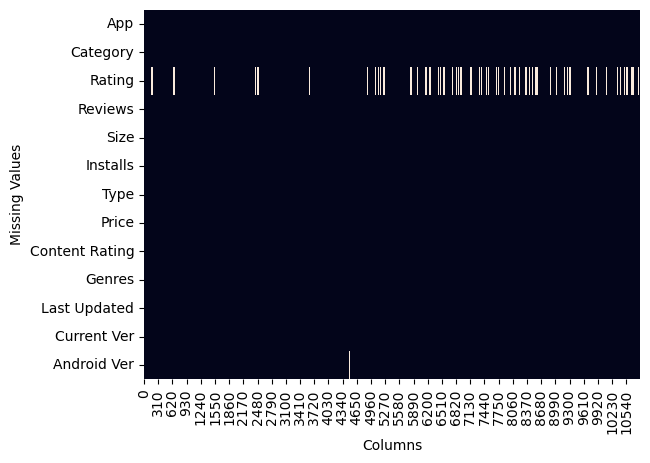

In [14]:
ax = plt.axes()
sns.heatmap(google_play_store_apps.isna().transpose(), cbar=False, ax=ax)

plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.show()

There is no much relation with missing inputs in ratings with the other columns. But missing info from current version and android version seems related.

In [ ]:
##Converting to numerical columns

In [19]:
google_play_store_apps["Reviews"] = pd.to_numeric(google_play_store_apps["Reviews"], errors="coerce")

In [21]:
google_play_store_apps["Installs"] = google_play_store_apps["Installs"].str.replace("[+,]", "", regex=True)

In [59]:
google_play_store_apps["Installs"] = pd.to_numeric(google_play_store_apps["Installs"], errors="coerce")

In [24]:
google_play_store_apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10840 non-null  float64
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
 13  Instals         10840 non-null  float64
dtypes: float64(3), object(11)
memory usage: 1.2+ MB


In [25]:
google_play_store_apps["Price"] = pd.to_numeric(google_play_store_apps["Price"], errors="coerce")

In [26]:
google_play_store_apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10840 non-null  float64
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10040 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
 13  Instals         10840 non-null  float64
dtypes: float64(4), object(10)
memory usage: 1.2+ MB


In [27]:
## Making Size column standardized

def size_to_mb(x):
    if isinstance(x, str):
        x = x.strip()
        if x.endswith("M"):
            return float(x.replace("M", ""))
        elif x.endswith("k") or x.endswith("K"):
            return float(x.replace("k", "").replace("K", "")) / 1024
        elif x == "Varies with device":
            return np.nan
    return np.nan

In [28]:
google_play_store_apps["Size_MB"] = google_play_store_apps["Size"].apply(size_to_mb)

In [30]:
google_play_store_apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10840 non-null  float64
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10040 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
 13  Instals         10840 non-null  float64
 14  Size_MB         9145 non-null   float64
dtypes: float64(5), object(10)
memory usage: 1.2+ MB


In [31]:
google_play_store_apps.head(20)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Instals,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,10000.0,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000.0,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,5000000.0,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,50000000.0,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,100000.0,2.8
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167.0,5.6M,50000,Free,0.0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up,50000.0,5.6
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178.0,19M,50000,Free,0.0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up,50000.0,19.0
7,Infinite Painter,ART_AND_DESIGN,4.1,36815.0,29M,1000000,Free,0.0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up,1000000.0,29.0
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791.0,33M,1000000,Free,0.0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up,1000000.0,33.0
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121.0,3.1M,10000,Free,0.0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up,10000.0,3.1


In [32]:
google_play_store_apps["Last Updated"] = pd.to_datetime(google_play_store_apps["Last Updated"], errors="coerce")

In [33]:
google_play_store_apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10841 non-null  object        
 1   Category        10841 non-null  object        
 2   Rating          9367 non-null   float64       
 3   Reviews         10840 non-null  float64       
 4   Size            10841 non-null  object        
 5   Installs        10841 non-null  object        
 6   Type            10840 non-null  object        
 7   Price           10040 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10841 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10833 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Instals         10840 non-null  float64       
 14  Size_MB         9145 non-null   float64       
dtypes:

In [34]:
google_play_store_apps.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Instals,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,10000.0,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,500000.0,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,5000000.0,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,50000000.0,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,100000.0,2.8


In [51]:
def standardize_version(x):
    if isinstance(x, str):
        if "Varies with device" in x:
            return np.nan
        x = x.replace("and up", "").strip()
        match = re.match(r"(\d+(\.\d+){0,2})", x)
        if match:
            return match.group(1)
    return np.nan

In [52]:
google_play_store_apps["curr_ver"] = google_play_store_apps["Current Ver"].apply(standardize_version)
google_play_store_apps["and_ver"] = google_play_store_apps["Android Ver"].apply(standardize_version)

In [53]:
def major_minor(ver_str):
    try:
        parts = ver_str.split(".")
        return float(".".join(parts[:2]))
    except:
        return np.nan

In [54]:
google_play_store_apps["and_ver_min"] = google_play_store_apps["and_ver"].apply(major_minor)
google_play_store_apps["curr_ver_min"] = google_play_store_apps["curr_ver"].apply(major_minor)

In [69]:
google_play_store_apps = google_play_store_apps.drop(["Instals"], axis = 1)

In [70]:
google_play_store_apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10841 non-null  object        
 1   Category        10841 non-null  object        
 2   Rating          9367 non-null   float64       
 3   Reviews         10840 non-null  float64       
 4   Size            10841 non-null  object        
 5   Installs        10840 non-null  float64       
 6   Type            10840 non-null  object        
 7   Price           10040 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10841 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10833 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Size_MB         9145 non-null   float64       
 14  curr_ver        9231 non-null   object        
 15  an

In [71]:
google_play_store_apps.head(7)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,curr_ver,and_ver,and_ver_min,curr_ver_min
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0,1.0.0,4.0.3,4.0,1.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0,2.0.0,4.0.3,4.0,2.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7,1.2.4,4.0.3,4.0,1.2
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0,NaN,4.2,4.2,NaN
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8,1.1,4.4,4.4,1.1
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167.0,5.6M,50000.0,Free,0.0,Everyone,Art & Design,2017-03-26,1.0,2.3 and up,5.6,1.0,2.3,2.3,1.0
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178.0,19M,50000.0,Free,0.0,Everyone,Art & Design,2018-04-26,1.1,4.0.3 and up,19.0,1.1,4.0.3,4.0,1.1


In [ ]:
## All datatypes converted, so checking null values again

In [72]:
print(google_play_store_apps.isnull().sum())

App                  0
Category             0
Rating            1474
Reviews              1
Size                 0
Installs             1
Type                 1
Price              801
Content Rating       1
Genres               0
Last Updated         1
Current Ver          8
Android Ver          3
Size_MB           1696
curr_ver          1610
and_ver           1365
and_ver_min       1365
curr_ver_min      1610
dtype: int64


In [73]:
print((google_play_store_apps.isnull().mean() * 100).round(2))

App                0.00
Category           0.00
Rating            13.60
Reviews            0.01
Size               0.00
Installs           0.01
Type               0.01
Price              7.39
Content Rating     0.01
Genres             0.00
Last Updated       0.01
Current Ver        0.07
Android Ver        0.03
Size_MB           15.64
curr_ver          14.85
and_ver           12.59
and_ver_min       12.59
curr_ver_min      14.85
dtype: float64


In [ ]:
## Now major null values are in Rating, Price, Size_MB, and_ver_min, curr_ver_min

/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


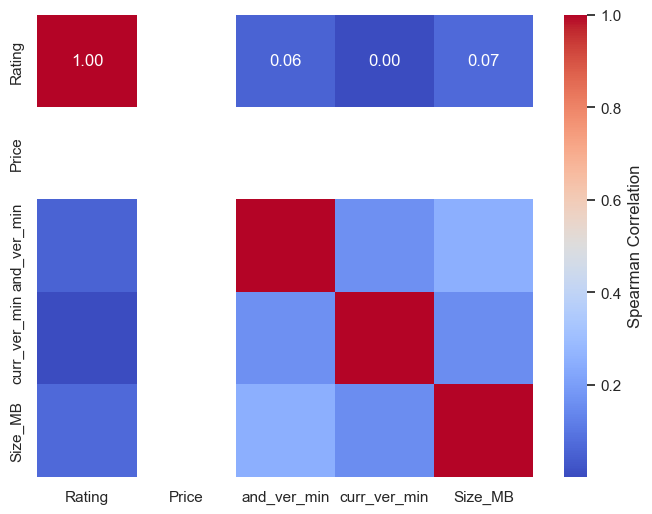

In [75]:
columns_of_interest = ["Rating", "Price", "and_ver_min", "curr_ver_min", "Size_MB"]

correlation_matrix = google_play_store_apps[columns_of_interest].corr(method="spearman")

sns.set_theme(style="white")
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"label" : "Spearman Correlation"})
plt.show()

In [ ]:
## Handling Missing Values

In [76]:
google_play_store_apps["Rating"].fillna(google_play_store_apps["Rating"].median(), inplace=True)
google_play_store_apps["Price"].fillna(0.0, inplace=True)
google_play_store_apps["Size_MB"].fillna(google_play_store_apps["Size_MB"].median(), inplace=True)
google_play_store_apps["and_ver_min"].fillna(google_play_store_apps["and_ver_min"].median(), inplace=True)
google_play_store_apps["curr_ver_min"].fillna(google_play_store_apps["curr_ver_min"].median(), inplace=True)
google_play_store_apps.dropna(subset=["Reviews", "Installs", "Type", "Content Rating", "Last Updated", ], inplace=True)

In [79]:
print(google_play_store_apps.isnull().sum())

App                  0
Category             0
Rating               0
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
Size_MB              0
curr_ver          1609
and_ver           1363
and_ver_min          0
curr_ver_min         0
dtype: int64


In [80]:
print((google_play_store_apps.isnull().mean() * 100).round(2))

App                0.00
Category           0.00
Rating             0.00
Reviews            0.00
Size               0.00
Installs           0.00
Type               0.00
Price              0.00
Content Rating     0.00
Genres             0.00
Last Updated       0.00
Current Ver        0.07
Android Ver        0.02
Size_MB            0.00
curr_ver          14.84
and_ver           12.57
and_ver_min        0.00
curr_ver_min       0.00
dtype: float64


In [81]:
google_play_store_apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,curr_ver,and_ver,and_ver_min,curr_ver_min
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0,1.0.0,4.0.3,4.0,1.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0,2.0.0,4.0.3,4.0,2.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7,1.2.4,4.0.3,4.0,1.2
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0,NaN,4.2,4.2,2.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8,1.1,4.4,4.4,1.1


In [82]:
google_play_store_apps["Category"].value_counts()

Category
FAMILY                 1971
GAME                   1144
TOOLS                   843
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         392
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     231
VIDEO_PLAYERS           175
EDUCATION               156
ENTERTAINMENT           149
MAPS_AND_NAVIGATION     137
FOOD_AND_DRINK          127
HOUSE_AND_HOME           88
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
Name: count, dtype: int64

In [83]:
def standardize_cat(x):
    if isinstance(x, str):
        x = x.strip()
        return x.split("_AND_")
    return np.nan

In [84]:
def standardize_gen(x):
    if isinstance(x, str):
        x = x.strip()
        return x.split(";")
    return np.nan

In [85]:
google_play_store_apps["Category"] = google_play_store_apps["Category"].apply(standardize_cat)
google_play_store_apps["Genres"] = google_play_store_apps["Genres"].apply(standardize_gen)

In [86]:
google_play_store_apps.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,curr_ver,and_ver,and_ver_min,curr_ver_min
0,Photo Editor & Candy Camera & Grid & ScrapBook,"[ART, DESIGN]",4.1,159.0,19M,10000.0,Free,0.0,Everyone,[Art & Design],2018-01-07,1.0.0,4.0.3 and up,19.0,1.0.0,4.0.3,4.0,1.0
1,Coloring book moana,"[ART, DESIGN]",3.9,967.0,14M,500000.0,Free,0.0,Everyone,"[Art & Design, Pretend Play]",2018-01-15,2.0.0,4.0.3 and up,14.0,2.0.0,4.0.3,4.0,2.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...","[ART, DESIGN]",4.7,87510.0,8.7M,5000000.0,Free,0.0,Everyone,[Art & Design],2018-08-01,1.2.4,4.0.3 and up,8.7,1.2.4,4.0.3,4.0,1.2
3,Sketch - Draw & Paint,"[ART, DESIGN]",4.5,215644.0,25M,50000000.0,Free,0.0,Teen,[Art & Design],2018-06-08,Varies with device,4.2 and up,25.0,NaN,4.2,4.2,2.0
4,Pixel Draw - Number Art Coloring Book,"[ART, DESIGN]",4.3,967.0,2.8M,100000.0,Free,0.0,Everyone,"[Art & Design, Creativity]",2018-06-20,1.1,4.4 and up,2.8,1.1,4.4,4.4,1.1
5,Paper flowers instructions,"[ART, DESIGN]",4.4,167.0,5.6M,50000.0,Free,0.0,Everyone,[Art & Design],2017-03-26,1.0,2.3 and up,5.6,1.0,2.3,2.3,1.0
6,Smoke Effect Photo Maker - Smoke Editor,"[ART, DESIGN]",3.8,178.0,19M,50000.0,Free,0.0,Everyone,[Art & Design],2018-04-26,1.1,4.0.3 and up,19.0,1.1,4.0.3,4.0,1.1
7,Infinite Painter,"[ART, DESIGN]",4.1,36815.0,29M,1000000.0,Free,0.0,Everyone,[Art & Design],2018-06-14,6.1.61.1,4.2 and up,29.0,6.1.61,4.2,4.2,6.1
8,Garden Coloring Book,"[ART, DESIGN]",4.4,13791.0,33M,1000000.0,Free,0.0,Everyone,[Art & Design],2017-09-20,2.9.2,3.0 and up,33.0,2.9.2,3.0,3.0,2.9
9,Kids Paint Free - Drawing Fun,"[ART, DESIGN]",4.7,121.0,3.1M,10000.0,Free,0.0,Everyone,"[Art & Design, Creativity]",2018-07-03,2.8,4.0.3 and up,3.1,2.8,4.0.3,4.0,2.8


In [87]:
google_play_store_apps = google_play_store_apps.drop(["Current Ver", "Android Ver"], axis = 1)

In [88]:
google_play_store_apps = google_play_store_apps.drop(["Size"], axis = 1)

In [89]:
google_play_store_apps.head(5)

,App,Category,Rating,Reviews,Installs,Type,Price,Content Rating,Genres,Last Updated,Size_MB,curr_ver,and_ver,and_ver_min,curr_ver_min
0,Photo Editor & Candy Camera & Grid & ScrapBook,"[ART, DESIGN]",4.1,159.0,10000.0,Free,0.0,Everyone,[Art & Design],2018-01-07,19.0,1.0.0,4.0.3,4.0,1.0
1,Coloring book moana,"[ART, DESIGN]",3.9,967.0,500000.0,Free,0.0,Everyone,"[Art & Design, Pretend Play]",2018-01-15,14.0,2.0.0,4.0.3,4.0,2.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...","[ART, DESIGN]",4.7,87510.0,5000000.0,Free,0.0,Everyone,[Art & Design],2018-08-01,8.7,1.2.4,4.0.3,4.0,1.2
3,Sketch - Draw & Paint,"[ART, DESIGN]",4.5,215644.0,50000000.0,Free,0.0,Teen,[Art & Design],2018-06-08,25.0,NaN,4.2,4.2,2.0
4,Pixel Draw - Number Art Coloring Book,"[ART, DESIGN]",4.3,967.0,100000.0,Free,0.0,Everyone,"[Art & Design, Creativity]",2018-06-20,2.8,1.1,4.4,4.4,1.1


In [90]:
print(google_play_store_apps.isnull().sum())

App                  0
Category             0
Rating               0
Reviews              0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Size_MB              0
curr_ver          1609
and_ver           1363
and_ver_min          0
curr_ver_min         0
dtype: int64


In [91]:
google_play_store_apps.to_csv("dataset/cleaned_googleplaystore.csv", index=False)
print("Cleaned dataset saved")

Cleaned dataset saved


In [2]:
df = pd.read_csv("dataset/cleaned_googleplaystore.csv")

df.head()

,App,Category,Rating,Reviews,Installs,Type,Price,Content Rating,Genres,Last Updated,Size_MB,curr_ver,and_ver,and_ver_min,curr_ver_min
0,Photo Editor & Candy Camera & Grid & ScrapBook,"['ART', 'DESIGN']",4.1,159.0,10000.0,Free,0.0,Everyone,['Art & Design'],2018-01-07,19.0,1.0.0,4.0.3,4.0,1.0
1,Coloring book moana,"['ART', 'DESIGN']",3.9,967.0,500000.0,Free,0.0,Everyone,"['Art & Design', 'Pretend Play']",2018-01-15,14.0,2.0.0,4.0.3,4.0,2.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...","['ART', 'DESIGN']",4.7,87510.0,5000000.0,Free,0.0,Everyone,['Art & Design'],2018-08-01,8.7,1.2.4,4.0.3,4.0,1.2
3,Sketch - Draw & Paint,"['ART', 'DESIGN']",4.5,215644.0,50000000.0,Free,0.0,Teen,['Art & Design'],2018-06-08,25.0,NaN,4.2,4.2,2.0
4,Pixel Draw - Number Art Coloring Book,"['ART', 'DESIGN']",4.3,967.0,100000.0,Free,0.0,Everyone,"['Art & Design', 'Creativity']",2018-06-20,2.8,1.1,4.4,4.4,1.1


In [4]:
app_names = df["App"].dropna().unique().tolist()

In [6]:
len(app_names)

9658

In [8]:
app_names

['Photo Editor & Candy Camera & Grid & ScrapBook',
 'Coloring book moana',
 'U Launcher Lite – FREE Live Cool Themes, Hide Apps',
 'Sketch - Draw & Paint',
 'Pixel Draw - Number Art Coloring Book',
 'Paper flowers instructions',
 'Smoke Effect Photo Maker - Smoke Editor',
 'Infinite Painter',
 'Garden Coloring Book',
 'Kids Paint Free - Drawing Fun',
 'Text on Photo - Fonteee',
 'Name Art Photo Editor - Focus n Filters',
 'Tattoo Name On My Photo Editor',
 'Mandala Coloring Book',
 '3D Color Pixel by Number - Sandbox Art Coloring',
 'Learn To Draw Kawaii Characters',
 'Photo Designer - Write your name with shapes',
 '350 Diy Room Decor Ideas',
 'FlipaClip - Cartoon animation',
 'ibis Paint X',
 'Logo Maker - Small Business',
 "Boys Photo Editor - Six Pack & Men's Suit",
 'Superheroes Wallpapers | 4K Backgrounds',
 'Mcqueen Coloring pages',
 'HD Mickey Minnie Wallpapers',
 'Harley Quinn wallpapers HD',
 'Colorfit - Drawing & Coloring',
 'Animated Photo Editor',
 'Pencil Sketch Drawing',

In [17]:
columns_of_interest = ["Rating", "Reviews", "Price", "Current Ver", "Android Ver"]

correlation_matrix = google_play_store_apps[columns_of_interest].corr(method="spearman")

sns.set_theme(style="white")
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"label" : "Spearman Correlation"})
plt.show()

ValueError: could not convert string to float: '3.0M'